LP qubit routing creation


We start with one simple change of the variables integrality. 

Okay, let's now create a simple non broken circuit, and see what will happen with the result. 

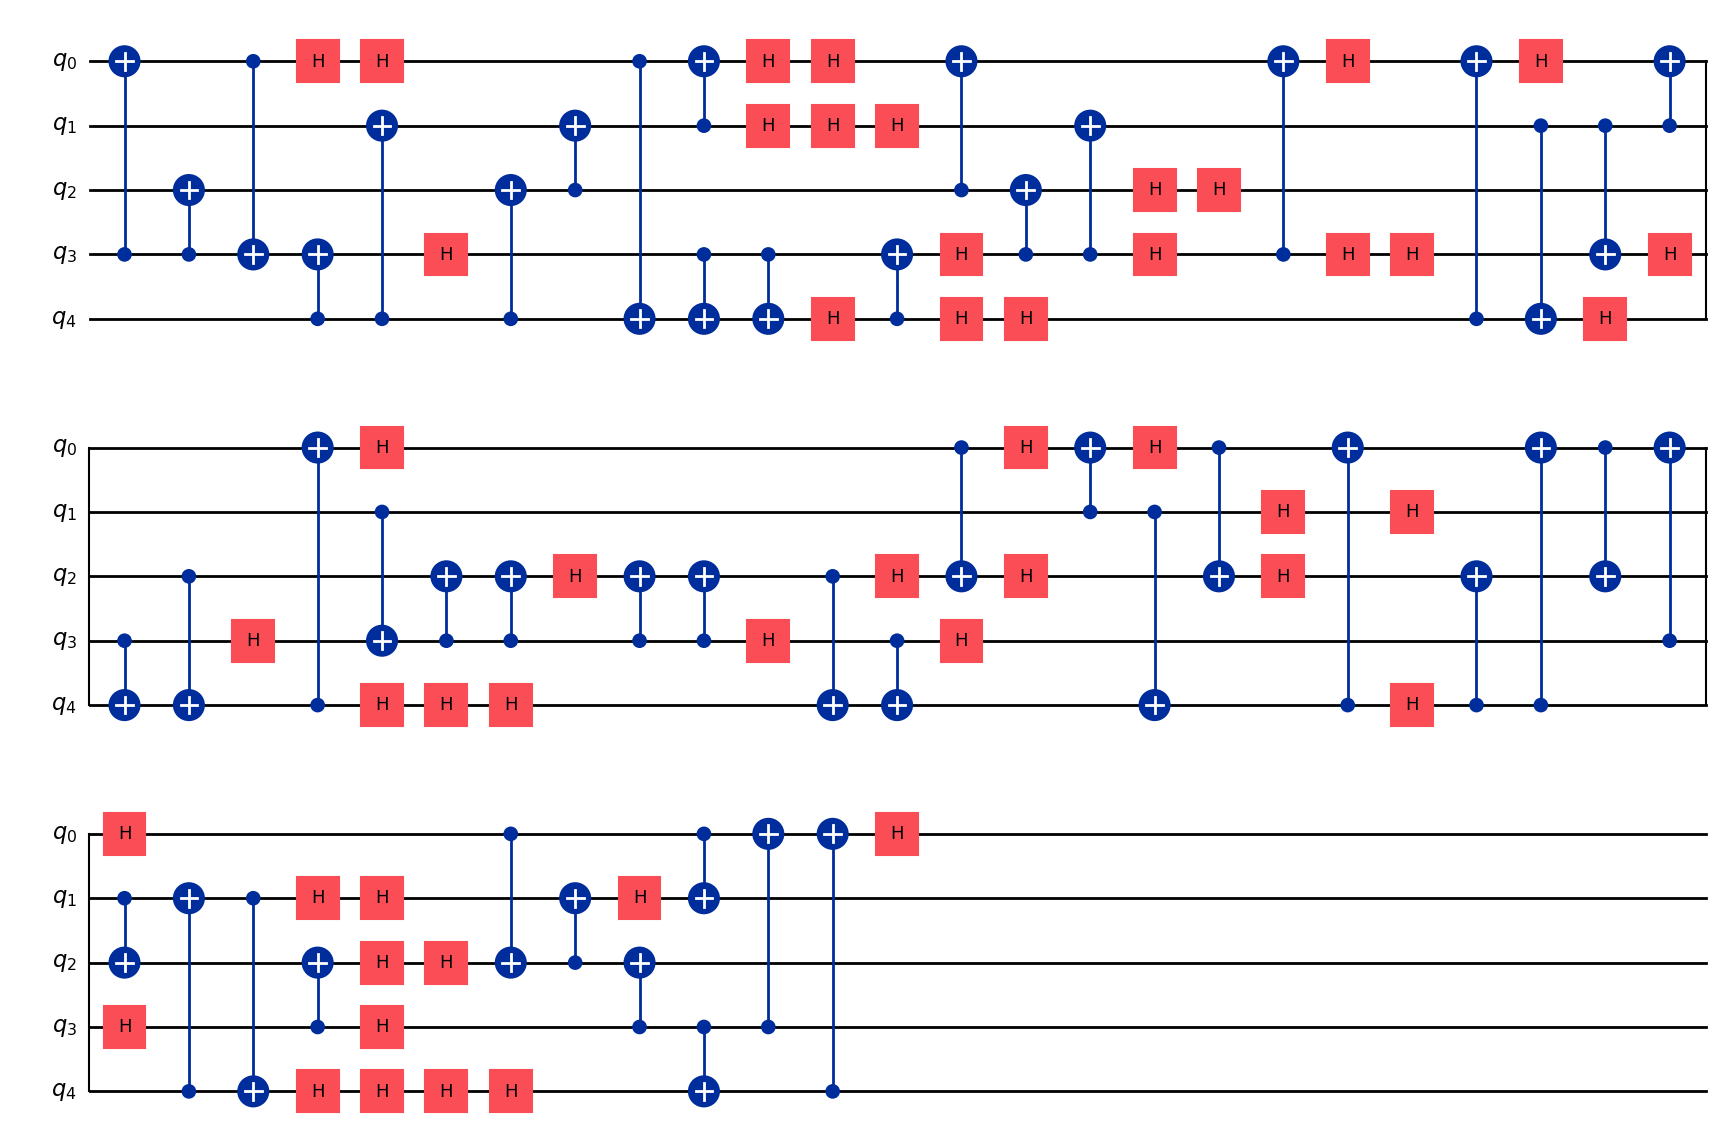

In [1]:
import qiskit.circuit.random
import qiskit
import qiskit.circuit.library.standard_gates
import random

import quariadne.circuit
import quariadne.routers

QUBIT_COUNT = 5
NUM_GATES = 100
SEED=2273
random.seed(SEED)

MAX_OPERANDS = 2

STANDARD_GATE_SET = ["cx", "h"]



random_broken_circuit = qiskit.circuit.random.random_clifford_circuit(QUBIT_COUNT, NUM_GATES, STANDARD_GATE_SET, seed=SEED)

random_broken_circuit.draw('mpl')

Now let's generate random backend coupling map)

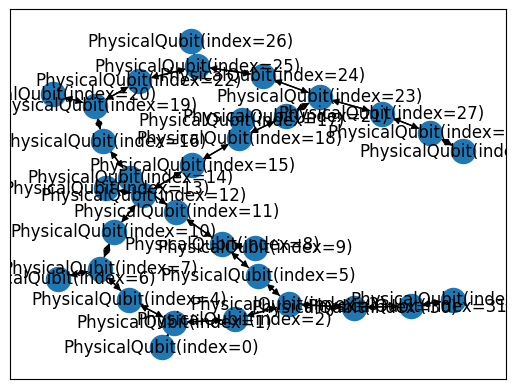

In [6]:
import qiskit_ibm_runtime.fake_provider 
import networkx as nx

manila_backend = qiskit_ibm_runtime.fake_provider.FakePrague()
coupling_graph = manila_backend.coupling_map.graph
coupling_graph_nx = nx.DiGraph()

coupling_map_qubits = manila_backend.coupling_map.physical_qubits
physical_qubits = tuple(quariadne.circuit.PhysicalQubit(coupling_map_qubit) for coupling_map_qubit in coupling_map_qubits)
coupling_map_edgelist = manila_backend.coupling_map.graph.edge_list()
physical_qubits_connections = tuple((quariadne.circuit.PhysicalQubit(coupling_map_from), quariadne.circuit.PhysicalQubit(coupling_map_to)) for coupling_map_from, coupling_map_to in coupling_map_edgelist)
physical_qubits, physical_qubits_connections
coupling_graph_nx.add_nodes_from(physical_qubits)
coupling_graph_nx.add_edges_from(physical_qubits_connections)
nx.draw_networkx(coupling_graph_nx)

Finally, let's see an encapsulated version of the ciurcuti

In [3]:
random_abstract_circuit = quariadne.circuit.AbstractQuantumCircuit.from_qiskit_circuit(random_broken_circuit)
random_abstract_circuit.operations

[QuantumOperation(name='cx', qubits_participating=(LogicalQubit(index=3), LogicalQubit(index=0))),
 QuantumOperation(name='cx', qubits_participating=(LogicalQubit(index=3), LogicalQubit(index=2))),
 QuantumOperation(name='cx', qubits_participating=(LogicalQubit(index=0), LogicalQubit(index=3))),
 QuantumOperation(name='h', qubits_participating=(LogicalQubit(index=0),)),
 QuantumOperation(name='cx', qubits_participating=(LogicalQubit(index=4), LogicalQubit(index=3))),
 QuantumOperation(name='cx', qubits_participating=(LogicalQubit(index=4), LogicalQubit(index=1))),
 QuantumOperation(name='h', qubits_participating=(LogicalQubit(index=0),)),
 QuantumOperation(name='h', qubits_participating=(LogicalQubit(index=3),)),
 QuantumOperation(name='cx', qubits_participating=(LogicalQubit(index=4), LogicalQubit(index=2))),
 QuantumOperation(name='cx', qubits_participating=(LogicalQubit(index=2), LogicalQubit(index=1))),
 QuantumOperation(name='cx', qubits_participating=(LogicalQubit(index=0), Logic

Let's initialise the milp router, and run it then!

In [4]:
import quariadne.milp
import numpy as np
import scipy.optimize
import quariadne.routers


from quariadne.milp import (
    MilpScipyRouter,
    INTEGER_VARIABLE_INTEGRALITY,
    CONTINUOUS_VARIABLE_INTEGRALITY,
    SwapEdge,
    create_gate_layers,
    GateLayer,
)

import networkx as nx




quariadne.routers.LpRouterEdges(coupling_graph_nx, random_abstract_circuit)

{<RoutingVariableType.MAPPING: 'mapping'>: {'shape': (200, 5, 5), 'flat_shape': np.int64(5000), 'offset': np.int64(0)}, <RoutingVariableType.GATE_EXECUTION: 'gate_execution'>: {'shape': (40, 50, 8), 'flat_shape': np.int64(16000), 'offset': np.int64(5000)}, <RoutingVariableType.QUBIT_MOVEMENT: 'qubit_movement'>: {'shape': (200, 5, 5, 5), 'flat_shape': np.int64(25000), 'offset': np.int64(21000)}}
        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 0.0
              x: [ 1.304e-01  3.478e-01 ...  0.000e+00  3.043e-01]
 mip_node_count: None
 mip_dual_bound: None
        mip_gap: None
0
1
4
5
[0, 4]
0
1
4
5
[5, 0]
2
3
6
7
[7, 2]
2
3
6
7
[7, 2]
0
1
4
5
[1, 4]
2
3
6
7
[2, 7]
2
3
6
7
[2, 6]
0
1
4
5
[4, 0]
0
1
6
7
[0, 6]
0
1
6
7
[1, 7]
2
3
6
7
[6, 2]
0
1
4
5
[5, 1]
0
1
6
7
[6, 0]
0
1
6
7
[7, 0]
2
3
6
7
[3, 6]
0
1
4
5
[4, 0]
0
1
6
7
[0, 6]
0
1
4
5
[4, 1]
0
1
4
5
[4, 0]
0
1
4
5
[5, 0]
2
3
6
7
[6, 2]
0
1
4
5
[5,